# Setup libraries 

In [1]:
import Pkg
Pkg.add([
        "CSV",
        "DataFrames",
        "Glob",
        "Makie",
        "CairoMakie",
        "Distributions",
        "HypothesisTests",
        "CategoricalArrays",
        "StatsBase",
        "Printf"
        ])

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
Precompiling project...
    628.1 ms  ✓ CategoricalArrays → CategoricalArraysStatsBaseExt
   2906.8 ms  ✓ Distributions
    652.5 ms  ✓ Distributions → DistributionsChainRulesCoreExt
    741.4 ms  ✓ Distributions → DistributionsTestExt
   1184.4 ms  ✓ HypothesisTests
   1027.1 ms  ✓ KernelDensity
  78012.8 ms  ✓ Makie
   6202.4 ms  ✓ GraphMakie
  29253.5 ms  ✓ CairoMakie
  46686.9 ms  ✓ GLMakie
  47688.6 ms  ✓ WGLMakie
  11 dependencies successfully precompiled in 132 seconds. 352 already precompiled.


In [2]:
import CSV
using Printf
using DataFrames
using CategoricalArrays
using Glob
using Makie, CairoMakie
using Statistics, Distributions, HypothesisTests, StatsBase
using ColorSchemes: tab10
using Colors

In [3]:
lerp(a::Color, b::Color, val::AbstractFloat) = (a .+ (val * (b .- a)))
th = Theme(
    colormap = :tab10,
    palette = Attributes(
        color = tab10,
        patchcolor = map(c -> lerp(RGB(1,1,1), c, 0.8f0), tab10)
    ),
    Axis = (
        colorrange = (1,10),
    ),
    Hist = (
        color = tab10[1],
    ),
)
set_theme!(merge(th))

# Import data

## Merge data from different files

In [4]:
colset = [
    "match_id",
    "ElapsedTime",
    "SetNo",
    # "P1GamesWon",
    # "P2GamesWon",
    "SetWinner",
    "GameNo",
    "GameWinner",
    "PointNumber",
    "PointWinner",
    "PointServer",
    # "Speed_KMH",
    "P1Score",
    "P2Score",
    "P1PointsWon",
    "P2PointsWon",
    # "P1Ace",
    # "P2Ace",
    # "P1Winner",
    # "P2Winner",
    # "P1DoubleFault",
    # "P2DoubleFault",
    # "P1UnfErr",
    # "P2UnfErr",
    "P1BreakPoint",
    "P2BreakPoint",
    "P1BreakPointWon",
    "P2BreakPointWon",
    # "P1SecondSrvIn",
    # "P2SecondSrvIn",
    # "P1SecondSrvWon",
    # "P2SecondSrvWon",
    # "P1ForcedError",
    # "P2ForcedError"
];

In [5]:
dfs = Dict(basename(f) => CSV.read(f, DataFrame) for f in glob("*points.csv", "tennis-data"))
tournaments = keys(dfs) |> collect |> sort
sorted_dfs = [dfs[t] for t in tournaments]
common_cols = intersect([names(df) for df in sorted_dfs]...);

In [6]:
all_matches = vcat([select!(df, colset) for df in sorted_dfs]...);

## Remove entire matches when necessary data are missing

In [7]:
df = all_matches
kept = []
required_cols = [
    :P1BreakPoint,
    :P2BreakPoint,
    :PointWinner,
    :PointNumber,
]
set_grps = groupby(df, [:match_id])
dfg = [grp for grp in set_grps if !any(ismissing.(Matrix(grp[:, required_cols])))];
df = vcat(dfg...)

println("Removed missing matches: $(length(set_grps) - length(dfg))")

Removed missing matches: 2087


## Add year, tournament, and match number

In [8]:
# add tournament and year columns
function from_matchid(mid)
    (year, tmnt) = match(r"(\d{4})-([a-z]+)", mid)
    year = parse(Int, year)
    permutedims([year, tmnt])
end

yr_tmnt = vcat(from_matchid.(df.match_id)...)
insertcols!(df, 2, :Year => yr_tmnt[:,1], :Tmnt => yr_tmnt[:,2]);

In [9]:
insertcols!(df, 4, :MatchNum => missing)
for gdf in groupby(df, :Year)
    gdf[!,:MatchNum] = groupindices(groupby(gdf, :match_id))
end

## Add player ids

In [10]:
mdf = vcat([CSV.read(f, DataFrame) for f in glob("*matches.csv", "clean-data")]...);

In [11]:
leftjoin!(df, mdf[:,[:match_id, :player1id, :player2id]], on = :match_id);

## Add BreakPoint, Tiebreaker and ServerWon columns

### BreakPoint column

In [12]:
df[:,:BreakPoint] = BitVector((df.P1BreakPoint) .+ (df.P2BreakPoint));

### Tiebreaker column

In [13]:
tb_games_ids = [
    Vector(grp[1, [:match_id, :SetNo, :GameNo]]) for grp in 
        groupby(df, [:match_id, :SetNo, :GameNo]) if
        any(Matrix(grp[:, [:P1Score, :P2Score]] .== "1"))
]
insertcols!(df, :Tiebreaker => zeros(Bool, nrow(df)))
for (id, setno, gameno) in tb_games_ids
    idx = df.match_id .== id .&& df.SetNo .== setno .&& df.GameNo .== gameno
    df[idx, :Tiebreaker] .= 1
end

### ServerWon column

In [14]:
insertcols!(df, :ServerWon => zeros(Bool, nrow(df)))
df[df.PointWinner .== df.PointServer, :ServerWon] .= 1;

## Import players

In [16]:
players = CSV.read("clean-data/players.csv", DataFrame)

Row,player,id
,String31,Int64
1,A Anisimova,1
2,A Balazs,2
3,A Barty,3
4,A Bedene,4
5,A Blinkova,5
6,A Bogdan,6
7,A Bolsova,7
8,A Bolt,8
9,A Bublik,9


## Save to other dataframe

In [18]:
data_main = df;

## Export data

In [28]:
function write_csv(filename, data; kwargs...)
    bool_cols = names(data, Bool)
    CSV.write(
        filename,
        transform(data, bool_cols .=> ByRow(Int) .=> bool_cols)
    )
end

write_csv (generic function with 1 method)

In [985]:
bool_cols = names(df, Bool)
CSV.write(
    joinpath("clean-data", "master-v1.csv"),
    transform(df, bool_cols .=> ByRow(Int) .=> bool_cols)
)

"clean-data/master-v1.csv"

## Take subset

In [29]:
dfg = groupby(df, :match_id)
dfs = vcat(sample(dfg |> collect, 500)...);

write_csv("clean-data/master-sub.csv", dfs)

"clean-data/master-sub.csv"

# Analysis

## Initialize dataframe

In [1141]:
df = dfs;

## Data characterization

Number of players

In [1142]:
vcat(df.player1id, df.player2id) |> unique |> length

583

In [1143]:
df2 = df[.! (ismissing.(df.player1id) .|| ismissing.(df.player2id)),:]
plmat = combine(
    groupby(select(df2, [:match_id, :player1id, :player2id]), :match_id),
    [:match_id, :player1id, :player2id] => 
    ((mid, p1, p2) -> hcat(first(mid), first(p1), first(p2))) => 
    [:match_id, :player1id, :player2id]
)

total_matches = vcat(
    select(plmat, :player1id => :id),
    select(plmat, :player2id => :id)
)

player_games = Dict(d.id[1] => length(d.id) for d in groupby(total_matches, :id));

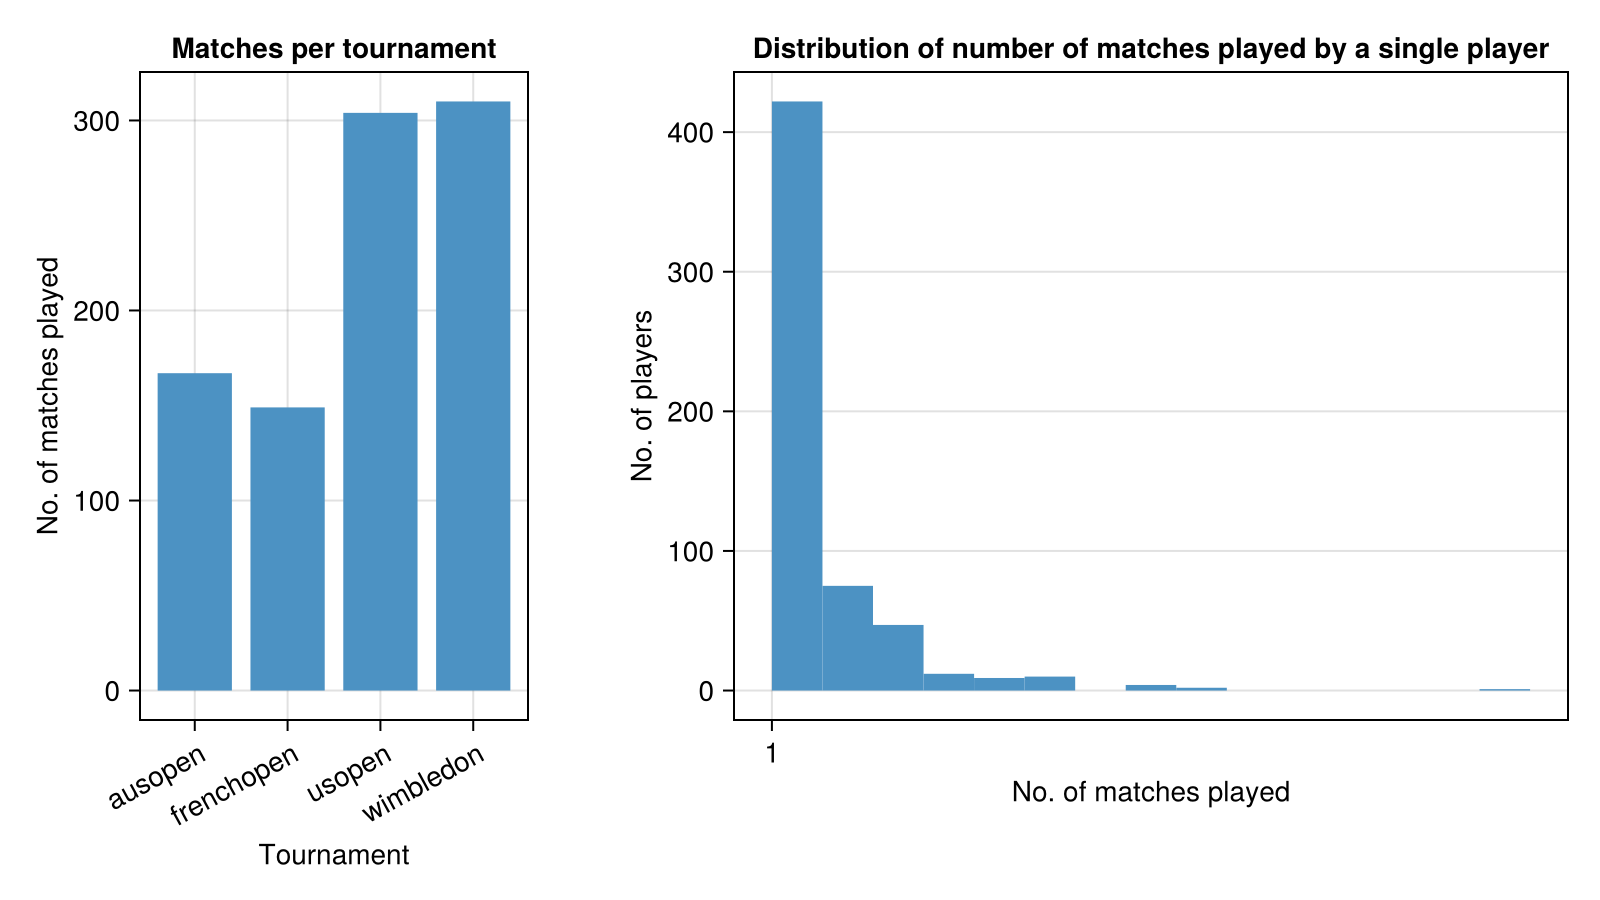

In [1144]:
tmnts = categorical([d.Tmnt[1] for d in groupby(df, :match_id)])
tmnt_counts = countmap(tmnts)

f = Figure(size = (800, 450))

ax1 = Axis(f[1,1], 
    xticklabelrotation = 0.5,
    title = "Matches per tournament",
    ylabel = "No. of matches played",
    xlabel = "Tournament",
    xticks = (1:4, String.(levels(tmnts))),
)
barplot!(
    levelcode.(tmnt_counts |> keys), 
    tmnt_counts |> values |> collect
)

ax2 = Axis(f[1,2],
    title = "Distribution of number of matches played by a single player",
    xlabel = "No. of matches played",
    ylabel = "No. of players",
    xticks = [1, floor.(range(40, maximum(values(player_games))+40, step = 40))...] |> collect,
)
plt = hist!(values(player_games) |> collect)

colsize!(f.layout, 1, Aspect(1, 3/5))
colsize!(f.layout, 2, Auto(0.7))
colgap!(f.layout, 50)
resize_to_layout!(f)

f

In [1124]:
CairoMakie.save(joinpath("figs", "tmnt_player_freq.png"), f)

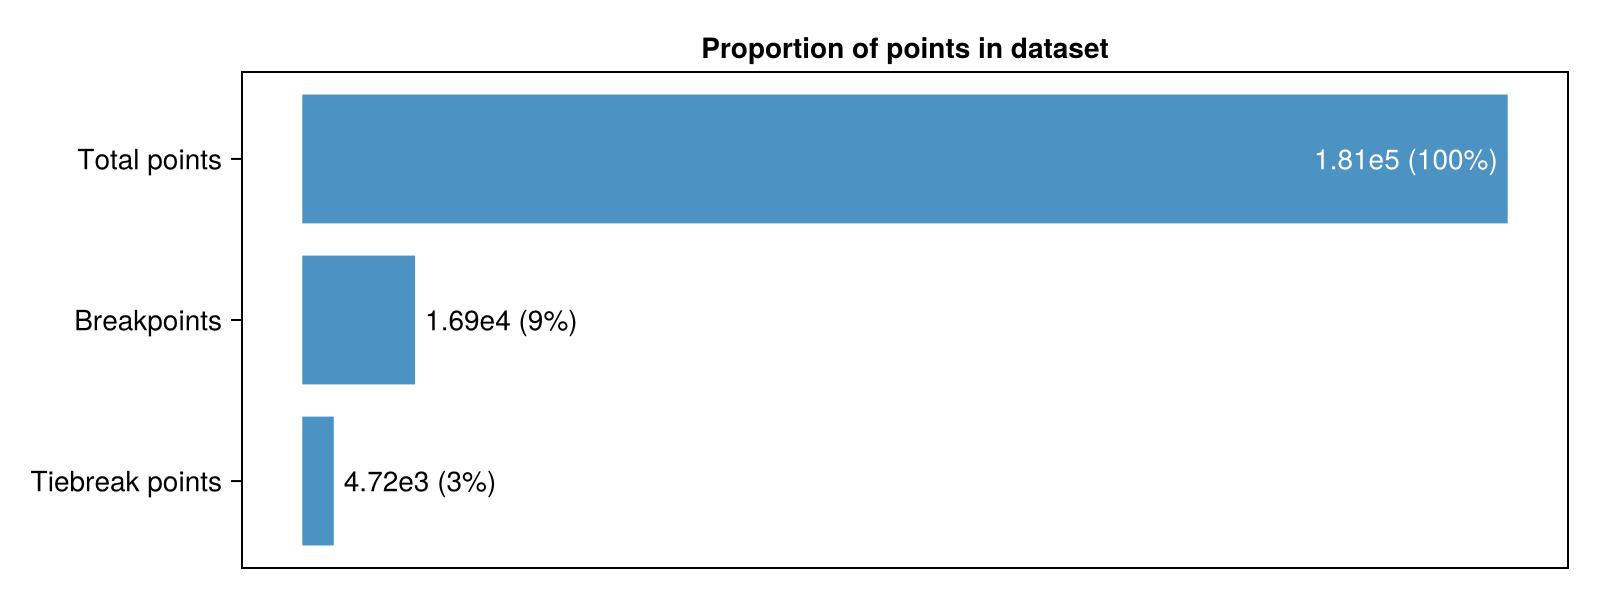

In [1145]:
n_games = nrow(df)
n_bp = nrow(df[df.BreakPoint,:])
n_tb = nrow(df[df.Tiebreaker,:])
bars = [n_games, n_bp, n_tb]
labels = [
    replace(
        @sprintf("%.2e (%.2d%%)", b, round(100 * b/n_games, sigdigits=2)),
        r"e\+0" => "e"
    ) for b in bars
]

plt = barplot(
    [3,2,1],
    bars,
    axis = (
        title = "Proportion of points in dataset",
        yticks = (1:3, ["Tiebreak points", "Breakpoints", "Total points"]),
        xticksvisible = false,
        xticklabelsvisible = false,
        xgridvisible = false,
        ygridvisible = false,
    ),
    bar_labels = labels,
    direction = :x,
    figure = (
        size = (800, 300),
    ),
    color_over_bar = :white,
    flip_labels_at = 0.85 * n_games,
)

In [1090]:
CairoMakie.save(joinpath("figs", "pointprops.png"), plt)

## Histogram of win probabilities

In [1146]:
gdf = groupby(df, [:match_id]);

In [1147]:
pws = zeros(length(gdf))
bpws = zeros(Union{Float64, Missing}, length(gdf))
for (i,g) in enumerate(gdf)
    gbp = g[g.BreakPoint,:]
    bpsw = mean(gbp.ServerWon)
    
    pwi = g.PointWinner .!= 0
    gpw = g[pwi,:]
    spw = mean(gpw.ServerWon)
    pws[i] = spw
    bpws[i] = bpsw
end
filter!((!) ∘ isnan, pws);
filter!((!) ∘ isnan, bpws);
# filter!((!) ∘ iszero, bps);

In [1008]:
println("Server wins:")
println("Mean: $(mean(pws))")
println("SD: $(std(pws))\n")

println("Breakpoint server wins:")
println("Mean: $(mean(bpws))")
println("SD: $(std(bpws))")

Server wins:
Mean: 0.6051056826391226
SD: 0.06064793627731757

Breakpoint server wins:
Mean: 0.5626271906370804
SD: 0.14240143508439637


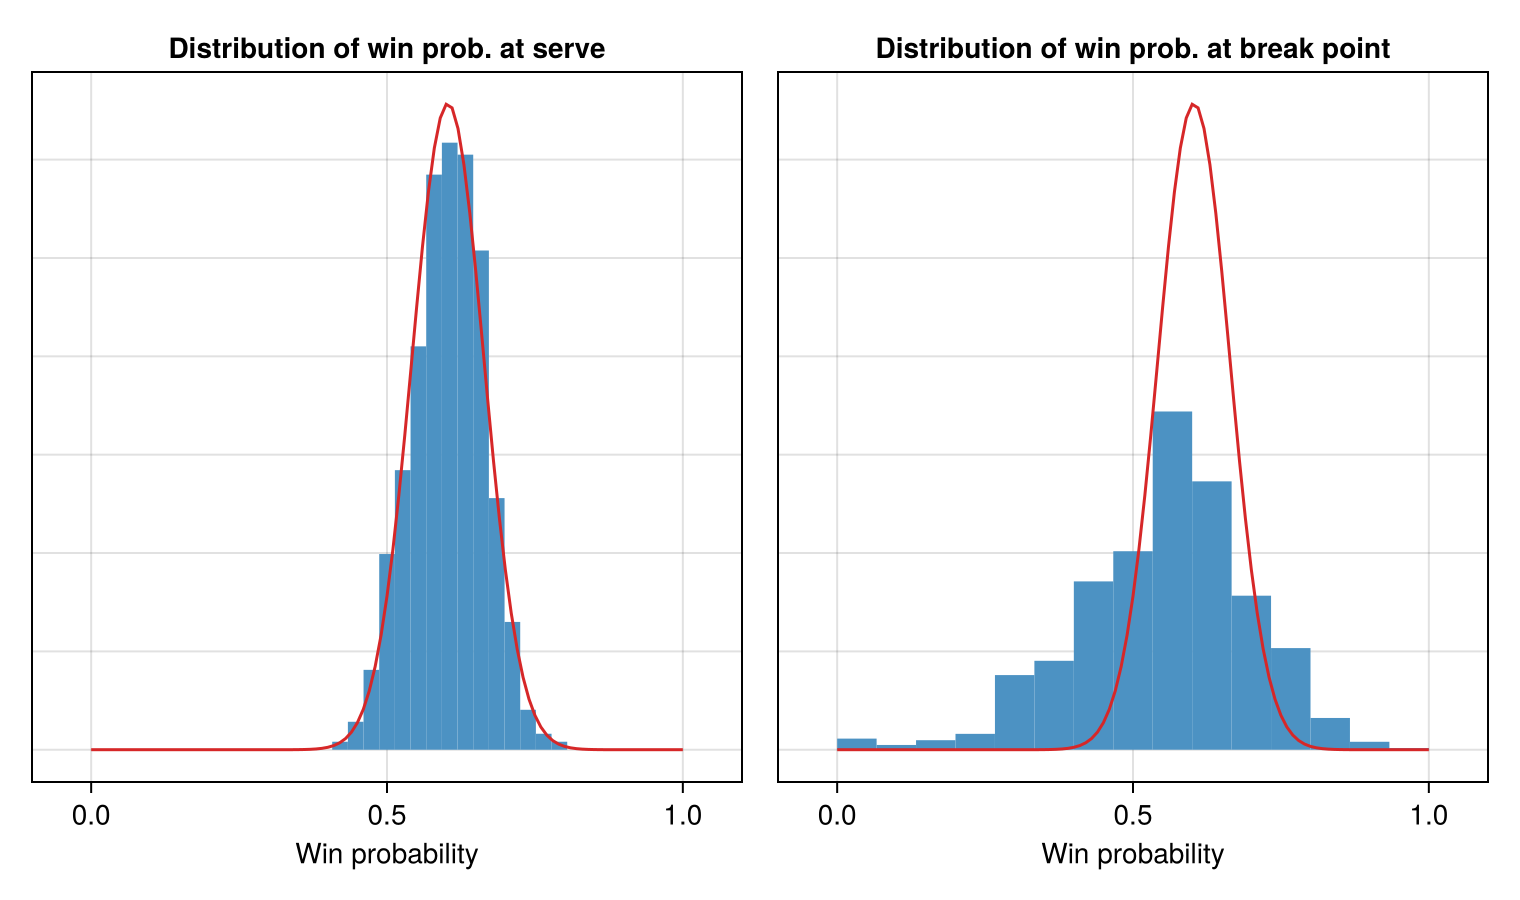

In [1148]:
mkax(f; kwargs...) = Axis(f,
    limits = ((-0.1,1.1), nothing);
    aspect = 1,
    xlabel = "Win probability",
    yticksvisible = false,
    yticklabelsvisible = false,
    kwargs...
)
f = Figure()
mkax(f[1,1], title = "Distribution of win prob. at serve")
hist!(pws, normalization = :pdf)
x = 0:0.01:1
y_pws = pdf(fit(Normal, pws), x)
lines!(x,y_pws, color = tab10[4])

mkax(f[1,2], title = "Distribution of win prob. at break point")
hist!(bpws, normalization = :pdf)
lines!(x,y_pws, color = tab10[4])

for c in 1:2
    colsize!(f.layout, c, Aspect(1,1.0))
end
resize_to_layout!(f)

f

In [522]:
CairoMakie.save("figs/win_prob_hists.png", f)

In [999]:
pws = zeros(length(gdf))
tbws = zeros(length(gdf))
for (i,g) in enumerate(gdf)
    gtb = g[g.Tiebreaker,:]
    tbsw = mean(gtb.ServerWon)
    
    pwi = g.PointWinner .!= 0
    gpw = g[pwi,:]
    spw = mean(gpw.ServerWon)
    pws[i] = spw
    tbws[i] = tbsw
end
filter!((!) ∘ isnan, pws);
filter!((!) ∘ isnan, tbws);

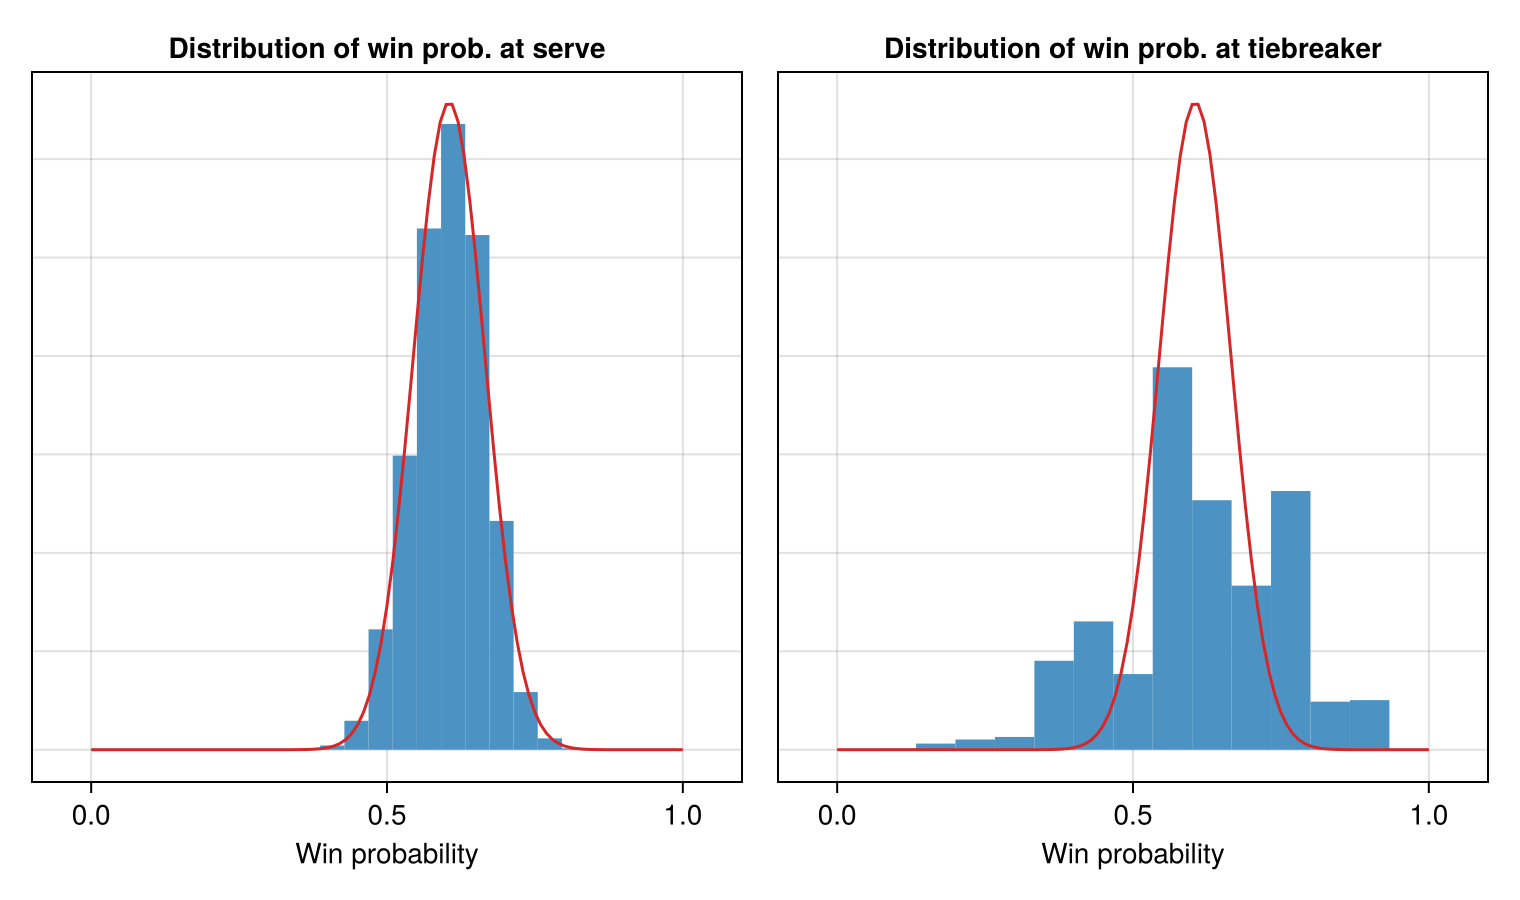

In [1125]:
mkax(f; kwargs...) = Axis(f,
    limits = ((-0.1,1.1), nothing);
    aspect = 1,
    xlabel = "Win probability",
    yticksvisible = false,
    yticklabelsvisible = false,
    kwargs...
)
f = Figure()
mkax(f[1,1], title = "Distribution of win prob. at serve")
hist!(pws, normalization = :pdf)
x = 0:0.01:1
y_pws = pdf(fit(Normal, pws), x)
lines!(x,y_pws, color = tab10[4])

mkax(f[1,2], title = "Distribution of win prob. at tiebreaker")
hist!(tbws, normalization = :pdf)
lines!(x,y_pws, color = tab10[4])

for c in 1:2
    colsize!(f.layout, c, Aspect(1,1.0))
end
resize_to_layout!(f)

f

In [1126]:
CairoMakie.save("figs/win_prob_tb_hists.png", f)

### Goodness of fit test 

We test the probability that the break point serve win probability distribution is the same as the estimated normal distribution of the win serve win probability. We use the fact that, for $X_i \sim N(0,1)$,
$$
\sum_i^n (X_i - \bar{X})^2 \sim \chi_{n-1}^2 \quad \text{where}\quad 
\bar{X} = \frac{1}{n} \sum_i^n X_i.
$$

In [997]:
d = fit(Normal, pws)
T = sum((tbws .- mean(d)).^2) / var(d)
p_pws = 1 - cdf(Chisq(length(tbws)-1), T)

0.0

Then we also do a Kolmogorov-Smirnov test.

In [998]:
pvalue(ApproximateTwoSampleKSTest(pws, skipmissing(tbws) |> collect))

2.5441272468384028e-141